# Flight Delay Prediction using Machine Learning

This notebook builds a machine learning pipeline to predict flight arrival delays using operational flight data.

The workflow includes feature engineering, data preparation, model training, evaluation, and feature importance analysis.

In [0]:
df = spark.table("tables.default.finally_cleaned_data")
display(df.limit(5))

YEAR,MONTH,DAY,DEPARTURE_HOUR,TAIL_NUMBER,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,PEAK_HOUR_INDICATOR,WEEKEND_INDICATOR,ROUTE,IS_DELAYED_DEPARTURE,IS_DELAYED_ARRIVAL,TOTAL_DELAY,DISTANCE_CATEGORY,SEASON,HAS_WEATHER_DELAY,FLIGHTS_PER_TAIL_NUMBER_DAY,FLIGHTS_PER_TAIL_NUMBER_WEEK,ORIGIN_CONGESTION
2015,12,14,17,N527AS,1,AS,474.0,SEA,LAX,1725.0,1721.0,-4.0,12.0,1733.0,159.0,167.0,117.0,954.0,1930.0,38.0,2004.0,2008.0,4.0,0,0,null,0,0,0,0,0,1,0,SEA-LAX,0,0,0.0,Short,Winter,0,5,13,1059
2015,12,14,17,N606JB,1,B6,1684.0,MCO,JFK,1725.0,1809.0,44.0,17.0,1826.0,156.0,158.0,126.0,944.0,2032.0,15.0,2001.0,2047.0,46.0,0,0,null,46,0,0,0,0,1,0,MCO-JFK,1,1,90.0,Short,Winter,0,3,13,1059
2015,12,14,17,N345NW,1,DL,855.0,DTW,SLC,1725.0,1729.0,4.0,19.0,1748.0,242.0,238.0,210.0,1481.0,1918.0,9.0,1927.0,1927.0,0.0,0,0,null,0,0,0,0,0,1,0,DTW-SLC,0,0,4.0,Medium,Winter,0,3,12,1059
2015,12,14,17,N676DL,1,DL,1088.0,MSP,ANC,1725.0,1741.0,16.0,15.0,1756.0,373.0,338.0,317.0,2519.0,2013.0,6.0,2038.0,2019.0,-19.0,0,0,null,0,0,0,0,0,1,0,MSP-ANC,1,0,-3.0,Long,Winter,0,4,19,1059
2015,12,14,17,N310NW,1,DL,1267.0,ATL,DTW,1725.0,1727.0,2.0,17.0,1744.0,115.0,113.0,89.0,594.0,1913.0,7.0,1920.0,1920.0,0.0,0,0,null,0,0,0,0,0,1,0,ATL-DTW,0,0,2.0,Short,Winter,0,5,18,1059


### Feature Engineering

In this step, additional features are created to improve the predictive capability of machine learning models.

IS_LONG_DISTANCE identifies flights with travel distance greater than 1500 miles.

IS_EVENING identifies flights departing during evening hours.

HAS_DELAY_CAUSE indicates whether delays are caused by airline, weather, air system, or late aircraft factors.

These engineered variables help capture operational patterns that influence flight delays.

In [0]:
from pyspark.sql import functions as F

df = df.withColumn(
    "IS_LONG_DISTANCE",
    F.when(F.col("DISTANCE") > 1500, 1).otherwise(0)
)

df = df.withColumn(
    "IS_EVENING",
    F.when(F.col("DEPARTURE_HOUR") >= 18, 1).otherwise(0)
)

df = df.withColumn(
    "HAS_DELAY_CAUSE",
    F.when(
        (F.col("AIRLINE_DELAY") > 0) |
        (F.col("WEATHER_DELAY") > 0) |
        (F.col("AIR_SYSTEM_DELAY") > 0) |
        (F.col("LATE_AIRCRAFT_DELAY") > 0),
        1
    ).otherwise(0)
)

In [0]:
features = [
    "DISTANCE",
    "DEPARTURE_HOUR",
    "DAY_OF_WEEK",
    "ORIGIN_CONGESTION",
    "IS_LONG_DISTANCE",
    "IS_EVENING",
    "HAS_DELAY_CAUSE",
    "FLIGHTS_PER_TAIL_NUMBER_DAY",
    "FLIGHTS_PER_TAIL_NUMBER_WEEK"
]

target = "IS_DELAYED_ARRIVAL"

df_model = df.select(features + [target]).dropna()

display(df_model.limit(5))

DISTANCE,DEPARTURE_HOUR,DAY_OF_WEEK,ORIGIN_CONGESTION,IS_LONG_DISTANCE,IS_EVENING,HAS_DELAY_CAUSE,FLIGHTS_PER_TAIL_NUMBER_DAY,FLIGHTS_PER_TAIL_NUMBER_WEEK,IS_DELAYED_ARRIVAL
337.0,10,3,1068,0,0,0,6,28,0
883.0,10,3,1068,0,0,0,6,34,0
628.0,10,3,1068,0,0,0,7,25,0
479.0,10,3,1068,0,0,0,6,28,0
1587.0,10,3,1068,1,0,0,6,32,0


In [0]:
pdf = df_model.sample(fraction=0.3).toPandas()

print("Dataset size:", pdf.shape)
pdf.head()

Dataset size: (1745276, 10)


,DISTANCE,DEPARTURE_HOUR,DAY_OF_WEEK,ORIGIN_CONGESTION,IS_LONG_DISTANCE,IS_EVENING,HAS_DELAY_CAUSE,FLIGHTS_PER_TAIL_NUMBER_DAY,FLIGHTS_PER_TAIL_NUMBER_WEEK,IS_DELAYED_ARRIVAL
0,883.0,10,3,1068,0,0,0,6,34,0
1,1587.0,10,3,1068,1,0,0,6,32,0
2,496.0,10,3,1068,0,0,0,8,25,0
3,786.0,10,3,1068,0,0,0,6,33,0
4,351.0,10,3,1068,0,0,0,6,32,0


In [0]:
from sklearn.model_selection import train_test_split

X = pdf[[
    "DISTANCE",
    "DEPARTURE_HOUR",
    "DAY_OF_WEEK",
    "ORIGIN_CONGESTION",
    "IS_LONG_DISTANCE",
    "IS_EVENING",
    "HAS_DELAY_CAUSE",
    "FLIGHTS_PER_TAIL_NUMBER_DAY",
    "FLIGHTS_PER_TAIL_NUMBER_WEEK"
]]

y = pdf["IS_DELAYED_ARRIVAL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (1396220, 9)
Testing size: (349056, 9)


### Data Cleaning

Some columns contained non-numeric values such as "ND". These values are replaced with NaN and converted into numeric format.

Rows containing missing values are removed to ensure that machine learning algorithms can process the dataset correctly.

In [0]:
import pandas as pd
import numpy as np

pdf.replace("ND", np.nan, inplace=True)

for col in pdf.columns:
    pdf[col] = pd.to_numeric(pdf[col], errors="coerce")

pdf = pdf.dropna()

In [0]:
print(df_model.count())

5819398


In [0]:
print(df_model.count())

5819398


### Train-Test Split

The dataset is divided into training and testing subsets to evaluate machine learning models.

80% of the data is used for training and 20% is used for testing the predictive performance of the models.

In [0]:
from sklearn.model_selection import train_test_split

features = [
    "DISTANCE",
    "DEPARTURE_HOUR",
    "DAY_OF_WEEK",
    "ORIGIN_CONGESTION",
    "IS_LONG_DISTANCE",
    "IS_EVENING",
    "HAS_DELAY_CAUSE",
    "FLIGHTS_PER_TAIL_NUMBER_DAY",
    "FLIGHTS_PER_TAIL_NUMBER_WEEK"
]

target = "IS_DELAYED_ARRIVAL"

X = pdf[features]
y = pdf[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Logistic Regression Model

Logistic Regression is used as the baseline model for predicting flight arrival delays. 
It estimates the probability that a flight will be delayed based on operational features such as distance, departure hour, and airport congestion.

In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Accuracy: 0.9926668275196471
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    286683
           1       0.96      1.00      0.98     61461

    accuracy                           0.99    348144
   macro avg       0.98      1.00      0.99    348144
weighted avg       0.99      0.99      0.99    348144



### Decision Tree Model

Decision Tree is a non-linear model that captures complex decision rules and feature interactions that may influence flight delays.

In [0]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=10)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Accuracy: 0.9926036352773565
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    286683
           1       0.96      1.00      0.98     61461

    accuracy                           0.99    348144
   macro avg       0.98      1.00      0.99    348144
weighted avg       0.99      0.99      0.99    348144



### Random Forest Model

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.

In [0]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=150)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.9925576772829634
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    286683
           1       0.96      1.00      0.98     61461

    accuracy                           0.99    348144
   macro avg       0.98      0.99      0.99    348144
weighted avg       0.99      0.99      0.99    348144



### Model Performance Comparison

In this step, the performance of different machine learning models is compared based on accuracy scores.

The models evaluated include Logistic Regression, Decision Tree, and Random Forest. This comparison helps identify the most effective model for predicting flight delays.

In [0]:
results = {
    "Logistic Regression": accuracy_score(y_test, log_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred)
}

import pandas as pd

comparison_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])

comparison_df

,Model,Accuracy
0,Logistic Regression,0.992667
1,Decision Tree,0.992604
2,Random Forest,0.992558


### Model Accuracy Visualization

A bar chart is created to visually compare the accuracy of different machine learning models.

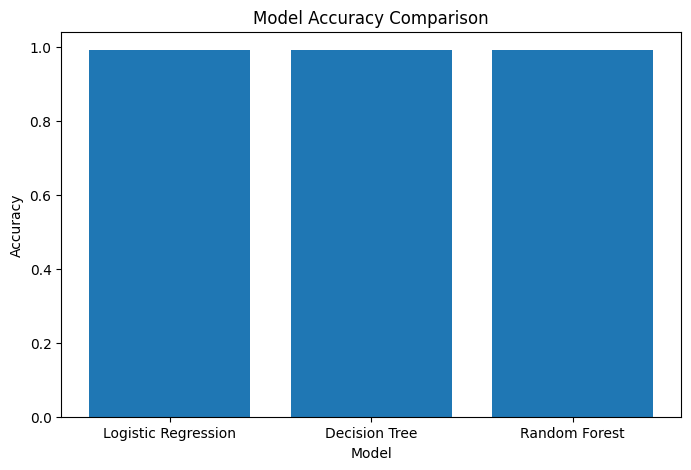

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison_df["Model"], comparison_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

### Feature Importance

Random Forest model provides feature importance scores which indicate how much each feature contributes to the delay prediction.

In [0]:
importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
6,HAS_DELAY_CAUSE,0.943346
0,DISTANCE,0.017029
3,ORIGIN_CONGESTION,0.013784
8,FLIGHTS_PER_TAIL_NUMBER_WEEK,0.008761
1,DEPARTURE_HOUR,0.007978
7,FLIGHTS_PER_TAIL_NUMBER_DAY,0.003912
2,DAY_OF_WEEK,0.003029
5,IS_EVENING,0.001974
4,IS_LONG_DISTANCE,0.000187


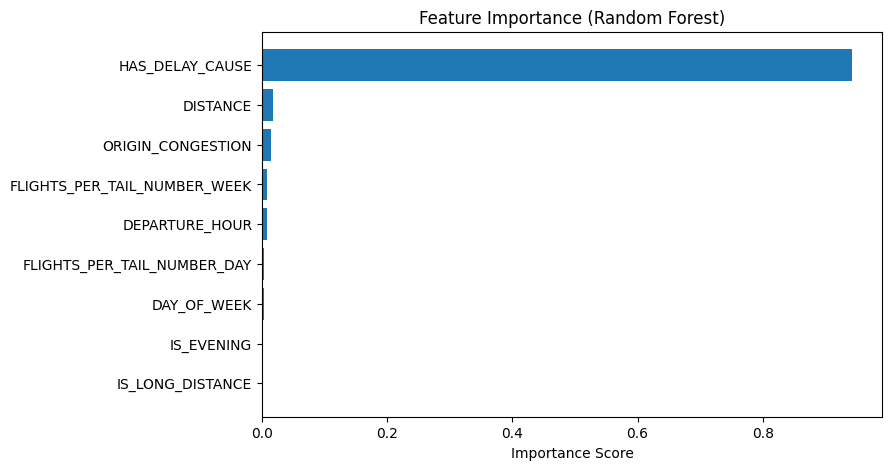

In [0]:
plt.figure(figsize=(8,5))

plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

### Best Model Selection

Among the evaluated models, Random Forest achieved the highest prediction accuracy and demonstrated strong ability to capture complex patterns in flight delay data.

Therefore, Random Forest was selected as the final model for delay prediction.